In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Read Excel file
excel_path = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Accuracy.xlsx'
df = pd.read_excel(excel_path)

# Display the dataframe to understand its structure
print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nFull DataFrame:")
print(df)


DataFrame shape: (16, 3)

Column names:
['Unnamed: 0', 'Euclidean distance Threshold=16', 'Unnamed: 2']

First few rows:
                    Unnamed: 0 Euclidean distance Threshold=16 Unnamed: 2
0  Synthetic Scaling & Texture                              F1   Accuracy
1    1x,1y,1z (Original Scale)                            0.81     0.6807
2                       2x1y1z                            0.86     0.7544
3                       1x2y1z                            0.87     0.7924
4                       1x1y2z                            0.84     0.7241

Full DataFrame:
                     Unnamed: 0 Euclidean distance Threshold=16 Unnamed: 2
0   Synthetic Scaling & Texture                              F1   Accuracy
1     1x,1y,1z (Original Scale)                            0.81     0.6807
2                        2x1y1z                            0.86     0.7544
3                        1x2y1z                            0.87     0.7924
4                        1x1y2z            

Names: ['1x,1y,1z (Original)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z', 'texture1', 'texture2', 'texture3', 'texture4', 'texture5']
F1 values: [0.81 0.86 0.87 0.84 0.82 0.88 0.8  0.67 0.82 0.69 0.7  0.78 0.81 0.9
 0.89]
Accuracy values: [0.6807 0.7544 0.7924 0.7241 0.6949 0.7875 0.6529 0.5986 0.7519 0.6115
 0.5785 0.6393 0.6807 0.81   0.809 ]


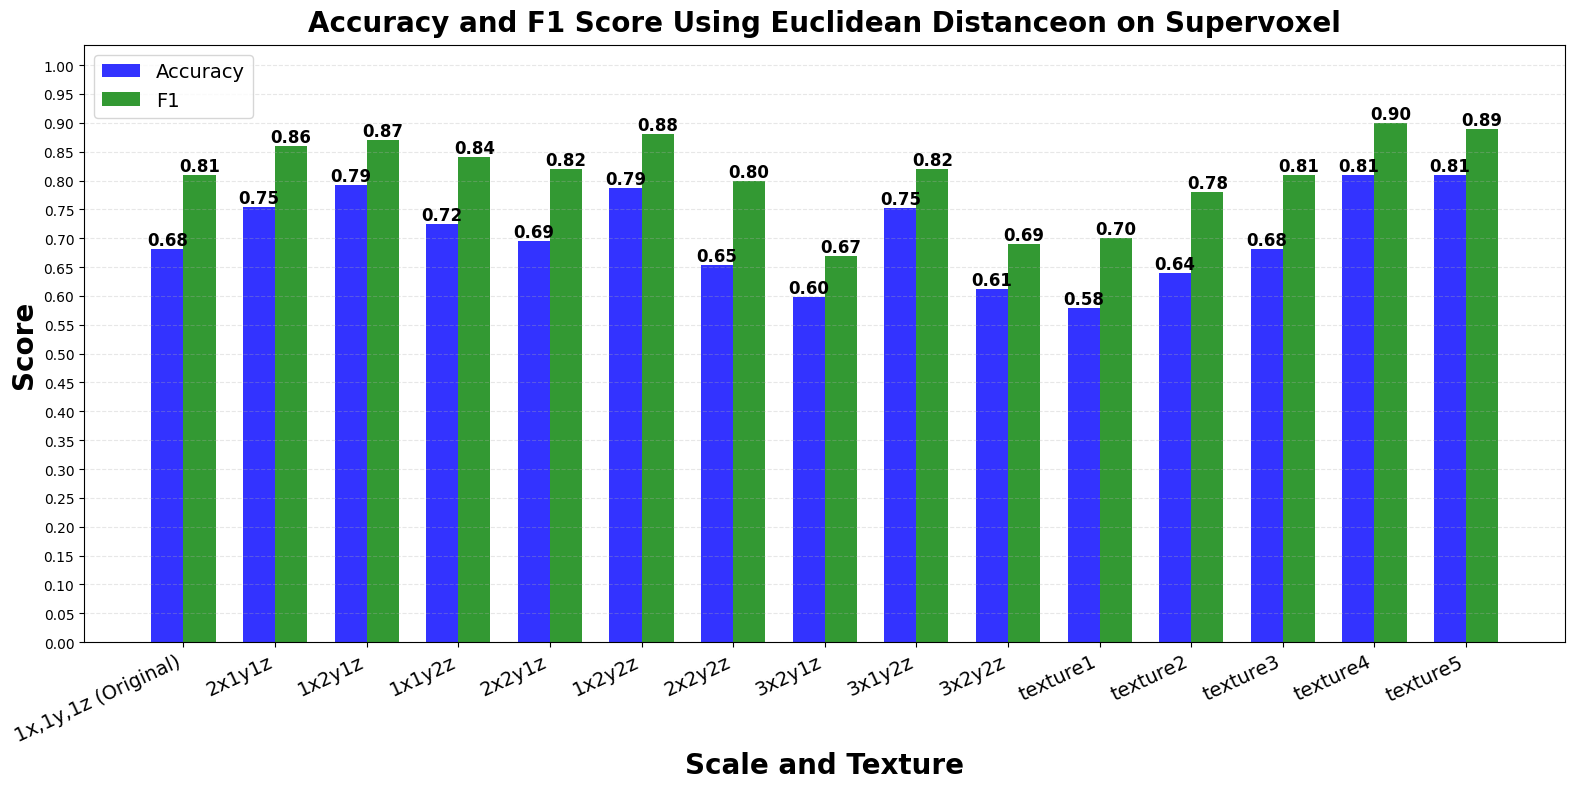

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file - first row contains headers, data starts from row 1
excel_path = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Accuracy.xlsx'
df_raw = pd.read_excel(excel_path, header=None)

# First row (index 0) contains column names: "Synthetic Scaling & Texture", "F1", "Accuracy"
# Data starts from row 1 (index 1), skip row 0 which is the header
names = df_raw.iloc[1:, 0].astype(str).tolist()  # First column, skip row 0
f1_values = pd.to_numeric(df_raw.iloc[1:, 1], errors='coerce').values  # Second column, skip row 0
acc_values = pd.to_numeric(df_raw.iloc[1:, 2], errors='coerce').values  # Third column, skip row 0

# Remove NaN values (first row was header)
names = [n for i, n in enumerate(names) if not (pd.isna(f1_values[i]) and pd.isna(acc_values[i]))]
f1_values = f1_values[~pd.isna(f1_values)]
acc_values = acc_values[~pd.isna(acc_values)]

print(f"Names: {names}")
print(f"F1 values: {f1_values}")
print(f"Accuracy values: {acc_values}")

# Create bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Set up bar positions
x = np.arange(len(names))
width = 0.35  # Width of bars

# Create bars
bars1 = ax.bar(x - width/2, acc_values, width, label='Accuracy', color='blue', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_values, width, label='F1', color='green', alpha=0.8)

# Add value labels on top of bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    # Accuracy value on top of blue bar
    height1 = bar1.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1,
            f'{acc_values[i]:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # F1 value on top of green bar
    height2 = bar2.get_height()
    ax.text(bar2.get_x() + bar2.get_width()/2., height2,
            f'{f1_values[i]:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the plot
ax.set_xlabel('Scale and Texture', fontsize=20, fontweight='bold')
ax.set_ylabel('Score', fontsize=20, fontweight='bold')
ax.set_title('Accuracy and F1 Score Using Euclidean Distanceon on Supervoxel', 
             fontsize=20, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=14)
ax.legend(fontsize=14)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits and ticks every 0.05
all_values = np.concatenate([acc_values, f1_values])
max_val = max(all_values) if len(all_values) > 0 else 1.0
ax.set_ylim(0, max_val * 1.15)
# Set y-axis ticks every 0.05
y_ticks = np.arange(0, max_val * 1.10 + 0.05, 0.05)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in y_ticks], fontsize=10)

plt.tight_layout()
plt.show()
